# Sales & Customer Analytics

Notebook ini berisi proses data understanding, data cleaning, exploratory analysis, SQL preparation, dan RFM customer analysis untuk project Sales & Customer Analytics.

In [ ]:
import pandas as pd

In [ ]:
file_path = "/content/drive/MyDrive/Sales-Customer-Analytics/data/Online Retail.xlsx"
df = pd.read_excel(file_path)

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df[df.duplicated(keep=False)].sort_values(
    by=["InvoiceNo", "StockCode"]
).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [ ]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [ ]:
#statistik Quantity khusus untuk transaksi cancellation.
df[df["InvoiceNo"].astype(str).str.startswith("C")]["Quantity"].describe()

,Quantity
count,9288.000000
mean,-29.885228
std,1145.786965
min,-80995.000000
25%,-6.000000
50%,-2.000000
75%,-1.000000
max,-1.000000


In [ ]:
df["UnitPrice"].describe()

,UnitPrice
count,541909.000000
mean,4.611114
std,96.759853
min,-11062.060000
25%,1.250000
50%,2.080000
75%,4.130000
max,38970.000000


In [ ]:
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [ ]:
df[df["UnitPrice"] < 0][["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID", "Country"]]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom


In [ ]:
df["Quantity"].describe()

,Quantity
count,541909.000000
mean,9.552250
std,218.081158
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000


In [ ]:
#memastikan apakah semua Quantity negatif memang cancellation atau ada pengecualian.
#menunjukkan berapa banyak Quantity negatif yang benar-benar memiliki InvoiceNo diawali C.
df[df["Quantity"] < 0]["InvoiceNo"].astype(str).str.startswith("C").value_counts()

,count
InvoiceNo,
True,9288
False,1336


In [ ]:
#Artinya, tidak semua quantity negatif adalah cancellation yang ditandai dengan C.
#perlu melihat 1.336 baris tersebut untuk mengetahui apa sebenarnya transaksinya.
df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
][[
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country"
]].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [ ]:
#apakah quantity = 0 juga ada.
(df["Quantity"] == 0).sum()

np.int64(0)

In [ ]:
#apakah transaksi tanpa CustomerID terkonsentrasi pada negara tertentu atau memang tersebar.
df[df["CustomerID"].isnull()]["Country"].value_counts().head(10)

,count
Country,
United Kingdom,133600
EIRE,711
Hong Kong,288
Unspecified,202
Switzerland,125
France,66
Israel,47
Portugal,39
Bahrain,2


In [ ]:
#negara mana saja yang ada dan berapa banyak transaksinya.
df["Country"].value_counts().head(15)

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


Temuan Dari Data Understanding Sebelum Cleaning:

- Dataset memiliki 541.909 baris dan 8 kolom.
- Terdapat 135.080 CustomerID kosong.
- Terdapat 1.454 Description kosong.
- Terdapat 5.268 duplicate rows.
- Terdapat 9.288 cancellation.
- Terdapat 2 transaksi UnitPrice negatif yang merupakan Adjust bad debt.
- Terdapat 1.336 quantity negatif non-cancellation dengan UnitPrice = 0.
- Tidak ada Quantity = 0.
- Penjualan sangat didominasi oleh United Kingdom.

In [ ]:
#tanggal transaksi paling awal dan paling akhir
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [ ]:
#mengetahui berapa banyak invoice/transaksi yang sebenarnya ada.
df["InvoiceNo"].nunique()

25900

Temuan: jumlah keseluruhan data dan unique invoice nya:

Rows: 541.909 → jumlah baris item transaksi
Invoices: 25.900 → jumlah transaksi/invoice unik

In [ ]:
#berapa banyak pelanggan dengan nilai unique
df["CustomerID"].nunique()

4372

In [ ]:
#berapa banyak produk unik yang tersedia berdasarkan StockCode.
df["StockCode"].nunique()

4070

In [ ]:
#apakah semua StockCode benar-benar merupakan produk, atau ada kode khusus untuk biaya, adjustment, postage, dan sebagainya.
df["StockCode"].value_counts().head(20)


,count
StockCode,
85123A,2313
22423,2203
85099B,2159
47566,1727
20725,1639
84879,1502
22720,1477
22197,1476
21212,1385


In [ ]:
#untuk melihat daftar StockCode yang mengandung huruf dan frekuensinya.
df[df["StockCode"].astype(str).str.contains(r"[A-Za-z]", regex=True)]["StockCode"].value_counts().head(30)

,count
StockCode,
85123A,2313
85099B,2159
POST,1256
85099C,960
82494L,943
85099F,842
DOT,710
M,571
84970S,546


In [ ]:
#melihat Description untuk menentukan jenis kodenya.
df[df["StockCode"].isin(["POST", "DOT", "M"])][
    ["StockCode", "Description", "Quantity", "UnitPrice"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description,Quantity,UnitPrice
379764,DOT,DOTCOM POSTAGE,1,195.37
183724,DOT,DOTCOM POSTAGE,1,118.38
183754,DOT,DOTCOM POSTAGE,1,168.63
183831,DOT,DOTCOM POSTAGE,1,181.83
183953,DOT,DOTCOM POSTAGE,1,135.67
...,...,...,...,...
235379,POST,POSTAGE,-1,545.58
298583,POST,POSTAGE,1,1.69
142988,POST,POSTAGE,1,350.00
56787,POST,POSTAGE,7,28.00


In [ ]:
# Mengecek arti StockCode "M" berdasarkan deskripsi, quantity, dan harga
df[df["StockCode"] == "M"][
    ["StockCode", "Description", "Quantity", "UnitPrice"]
].drop_duplicates()

,StockCode,Description,Quantity,UnitPrice
2239,M,Manual,1,1.25
2250,M,Manual,1,18.95
5684,M,Manual,1,2.55
6798,M,Manual,2,0.85
7976,M,Manual,12,0.42
...,...,...,...,...
526015,M,Manual,1,219.50
526018,M,Manual,800,0.25
531432,M,Manual,4,1.25
534308,M,Manual,-1,9.95


Temuan KOde Khusus Didalam fitur StockCode

| StockCode | Description | Kategori |
| --------- | -------------- | ---------------- |
| `POST` | POSTAGE | Biaya pengiriman |
| `DOT` | DOTCOM POSTAGE | Biaya pengiriman |
| `M` | Manual | Transaksi manual |

In [ ]:
# Mencari StockCode yang hanya berupa huruf untuk menemukan kode khusus lainnya
df[df["StockCode"].astype(str).str.fullmatch(r"[A-Za-z]+")]["StockCode"].value_counts()

,count
StockCode,
POST,1256
DOT,710
M,571
D,77
S,63
AMAZONFEE,34
CRUK,16
DCGSSGIRL,13
DCGSSBOY,11


Temuan Sementara Selanjutnya:

| StockCode | Jumlah | Catatan |
| ----------- | -----: | ------------------------ |
| `POST` | 1.256 | Postage |
| `DOT` | 710 | Dotcom postage |
| `M` | 571 | Manual |
| `D` | 77 | **Perlu diperiksa** |
| `S` | 63 | **Perlu diperiksa** |
| `AMAZONFEE` | 34 | Kemungkinan biaya Amazon |
| `CRUK` | 16 | **Perlu diperiksa** |
| `DCGSSGIRL` | 13 | **Perlu diperiksa** |
| `DCGSSBOY` | 11 | **Perlu diperiksa** |
| `PADS` | 4 | **Perlu diperiksa** |
| `B` | 3 | **Perlu diperiksa** |
| `m` | 1 | Perlu diperiksa |

In [ ]:
# Melihat deskripsi, quantity, dan harga dari StockCode khusus untuk menentukan jenis transaksinya
special_codes = [
    "POST", "DOT", "M", "D", "S", "AMAZONFEE",
    "CRUK", "DCGSSGIRL", "DCGSSBOY", "PADS", "B", "m"
]

df[df["StockCode"].isin(special_codes)][
    ["StockCode", "Description", "Quantity", "UnitPrice"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description,Quantity,UnitPrice
524601,AMAZONFEE,AMAZON FEE,-1,11586.50
342611,AMAZONFEE,AMAZON FEE,-1,5522.14
124741,AMAZONFEE,AMAZON FEE,-1,5693.05
96845,AMAZONFEE,AMAZON FEE,-1,5258.77
312092,AMAZONFEE,AMAZON FEE,-1,4527.65
...,...,...,...,...
96710,S,SAMPLES,-1,37.49
96711,S,SAMPLES,-1,31.98
96713,S,SAMPLES,-1,4.59
414147,S,SAMPLES,-1,33.05


In [ ]:
# Mengecek deskripsi dan detail transaksi dari StockCode yang belum kita identifikasi
unknown_codes = ["D", "CRUK", "DCGSSGIRL", "DCGSSBOY", "PADS", "B"]

df[df["StockCode"].isin(unknown_codes)][
    ["StockCode", "Description", "Quantity", "UnitPrice"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description,Quantity,UnitPrice
299982,B,Adjust bad debt,1,11062.060
299983,B,Adjust bad debt,1,-11062.060
494745,CRUK,CRUK Commission,-1,849.930
467437,CRUK,CRUK Commission,-1,1038.750
455284,CRUK,CRUK Commission,-1,517.510
...,...,...,...,...
278379,DCGSSGIRL,GIRLS PARTY BAG,5,1.250
84017,DCGSSGIRL,GIRLS PARTY BAG,3,3.290
150864,DCGSSGIRL,GIRLS PARTY BAG,1,3.290
157195,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001


Temuan StockCode Tambahan:

| StockCode | Description | Interpretasi |
| ----------- | -------------------------- | ---------------------------------------------- |
| `B` | Adjust bad debt | **Penyesuaian piutang/bad debt**, bukan produk |
| `CRUK` | CRUK Commission | **Komisi**, bukan produk |
| `DCGSSGIRL` | GIRLS PARTY BAG | **Produk** |
| `DCGSSBOY` | GIRLS/BOYS PARTY BAG | **Produk** |
| `PADS` | PADS TO MATCH ALL CUSHIONS | **Produk/aksesori** |

In [ ]:
# Mengecek pola transaksi StockCode "D" untuk menentukan apakah termasuk produk atau transaksi khusus
df[df["StockCode"] == "D"][
    ["StockCode", "Description", "Quantity", "UnitPrice", "InvoiceNo"]
].drop_duplicates()

,StockCode,Description,Quantity,UnitPrice,InvoiceNo
141,D,Discount,-1,27.50,C536379
9038,D,Discount,-1,29.29,C537164
14498,D,Discount,-1,281.00,C537597
19392,D,Discount,-1,267.12,C537857
31134,D,Discount,-1,5.76,C538897
...,...,...,...,...,...
479868,D,Discount,-1,19.82,C577227
479869,D,Discount,-1,16.76,C577227
493613,D,Discount,-1,26.33,C578239
516221,D,Discount,-1,20.53,C579884


Rekap Temuan Temuan Dari Data Understanding:

| StockCode | Description | Kategori | Produk? | Temuan / Alasan |
| ----------- | -------------------------- | ---------------- | :-----: | ----------------------------------------------------------------------------------- |
| `85123A` | Produk (nama produk) | Produk | | Kode mengandung huruf, tetapi merupakan kode produk normal |
| `85099B` | Produk (nama produk) | Produk | | Kode mengandung huruf, tetapi merupakan kode produk normal |
| `DCGSSGIRL` | GIRLS PARTY BAG | Produk | | Deskripsi merupakan barang dan memiliki transaksi quantity positif |
| `DCGSSBOY` | BOYS PARTY BAG | Produk | | Deskripsi merupakan barang dan memiliki transaksi quantity positif |
| `PADS` | PADS TO MATCH ALL CUSHIONS | Produk/aksesori | | Memiliki deskripsi barang; termasuk produk/aksesori meskipun harganya sangat rendah |
| `POST` | POSTAGE | Biaya pengiriman | | Merupakan biaya postage, bukan barang |
| `DOT` | DOTCOM POSTAGE | Biaya pengiriman | | Merupakan biaya pengiriman |
| `M` / `m` | Manual | Transaksi manual | | Menunjukkan transaksi manual, bukan produk reguler |
| `D` | Discount | Diskon | | Quantity `-1`, deskripsi Discount; merupakan potongan harga |
| `AMAZONFEE` | AMAZON FEE | Biaya | | Merupakan biaya Amazon |
| `CRUK` | CRUK Commission | Komisi | | Merupakan biaya/komisi |
| `B` | Adjust bad debt | Penyesuaian | | Merupakan penyesuaian bad debt, bukan barang |

Temuan Berdasarkan Quantity:

| Kondisi | Jumlah | Interpretasi |
| ------------------------------------------ | --------: | ------------------------------------------------- |
| `Quantity < 0` + Invoice diawali `C` | **9.288** | Cancellation/pembatalan |
| `Quantity < 0` + Invoice tidak diawali `C` | **1.336** | Transaksi khusus/penyesuaian yang perlu diperiksa |
| `Quantity = 0` | **0** | Tidak ditemukan |
| `Quantity > 0` | Mayoritas | Transaksi dengan jumlah positif |

Temuan Data Lainya:

| Temuan | Hasil |
| ------------------------------------ | --------------------------: |
| Total baris | **541.909** |
| Total kolom | **8** |
| Missing `Description` | **1.454** |
| Missing `CustomerID` | **135.080** |
| Duplicate rows | **5.268** |
| Cancellation (`InvoiceNo` diawali C) | **9.288** |
| `UnitPrice < 0` | **2 baris** |
| Unique Invoice | **25.900** |
| Unique CustomerID | **4.372** |
| Unique StockCode | **4.070** |
| Periode data | **1 Des 2010 – 9 Des 2011** |

Kesimpulan Sementara dari Data Understanding:

### Kesimpulan Data Understanding

Berdasarkan hasil pemeriksaan dataset, dapat disimpulkan bahwa data transaksi terdiri dari **541.909 baris dan 8 atribut**, dengan periode transaksi dari **1 Desember 2010 hingga 9 Desember 2011**. Dataset memiliki **25.900 invoice, 4.372 customer, dan 4.070 StockCode unik**.

Dalam proses pemahaman data, ditemukan beberapa kondisi yang perlu diperhatikan sebelum melakukan analisis, yaitu terdapat **5.268 data duplikat**, **1.454 nilai kosong pada Description**, dan **135.080 nilai kosong pada CustomerID**. Selain itu, terdapat **9.288 transaksi pembatalan** yang ditandai dengan `InvoiceNo` diawali `C`, serta **1.336 transaksi dengan Quantity negatif** yang tidak termasuk cancellation dan perlu ditangani secara khusus.

Pemeriksaan terhadap `StockCode` juga menunjukkan bahwa **tidak semua kode yang mengandung huruf merupakan transaksi non-produk**. Beberapa kode seperti `DCGSSGIRL`, `DCGSSBOY`, dan `PADS` masih dapat dikategorikan sebagai produk berdasarkan deskripsi dan pola transaksinya. Sebaliknya, kode seperti `POST`, `DOT`, `M`, `D`, `AMAZONFEE`, `CRUK`, dan `B` merupakan transaksi khusus seperti biaya pengiriman, transaksi manual, diskon, komisi, atau penyesuaian.

Dengan demikian, **data tidak dapat dibersihkan hanya berdasarkan satu atribut**, tetapi perlu mempertimbangkan kombinasi `StockCode`, `Description`, `Quantity`, `UnitPrice`, dan `InvoiceNo`. Temuan ini akan menjadi dasar dalam menentukan **aturan Data Cleaning** pada tahap berikutnya, sehingga data yang digunakan untuk analisis penjualan tetap relevan dan tidak menghilangkan informasi penting secara sembarangan.

#Data Cleaning

In [ ]:
# Membuat salinan dataset mentah sebagai dataset yang akan digunakan untuk proses Data Cleaning
cleaned_df = df.copy()

print("Jumlah baris awal:", len(cleaned_df))
print("Jumlah kolom awal:", len(cleaned_df.columns))

Jumlah baris awal: 541909
Jumlah kolom awal: 8


In [ ]:
# Menghapus baris yang seluruh nilainya sama agar transaksi tidak terhitung lebih dari satu kali
cleaned_df = cleaned_df.drop_duplicates()

print("Jumlah baris setelah menghapus duplikat:", len(cleaned_df))
print("Jumlah duplikat setelah dibersihkan:", cleaned_df.duplicated().sum())

Jumlah baris setelah menghapus duplikat: 536641
Jumlah duplikat setelah dibersihkan: 0


In [ ]:
# Mengecek karakteristik transaksi yang memiliki Description kosong sebelum menentukan tindakan cleaning
missing_description = cleaned_df[cleaned_df["Description"].isna()]

print("Jumlah Description kosong:", len(missing_description))
print("\nDistribusi Quantity:")
print(missing_description["Quantity"].value_counts().head())

print("\nDistribusi UnitPrice:")
print(missing_description["UnitPrice"].describe())

print("\nDistribusi InvoiceNo yang diawali C:")
print(
    missing_description["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .value_counts()
)

Jumlah Description kosong: 1454

Distribusi Quantity:
Quantity
 1    126
-1     73
 2     66
-2     52
-5     40
Name: count, dtype: int64

Distribusi UnitPrice:
count    1454.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: UnitPrice, dtype: float64

Distribusi InvoiceNo yang diawali C:
InvoiceNo
False    1454
Name: count, dtype: int64


Analisis Deskripsi Kosong (sementara):

| Pemeriksaan | Hasil | Kesimpulan |
| ------------------------ | -----------------------: | -------------------------------- |
| `Description` kosong | **1.454** | Perlu ditangani |
| `UnitPrice` | **semuanya 0** | Tidak memiliki nilai penjualan |
| `InvoiceNo` cancellation | **0** | Bukan cancellation |
| `Quantity` | Positif & negatif | Ada transaksi/penyesuaian |
| `UnitPrice` | **0 pada seluruh baris** | Tidak berkontribusi pada revenue |

In [ ]:
# Mengecek StockCode pada transaksi yang Description-nya kosong untuk mengetahui apakah ada pola tertentu
missing_description["StockCode"].value_counts().head(20)

,count
StockCode,
23084,10
35965,10
22084,9
22451,6
22501,5
21784,5
21033,5
22866,5
23348,5


In [ ]:
# Mengecek apakah StockCode dengan Description kosong memiliki Description yang tersedia pada transaksi lain
description_check = (
    cleaned_df.groupby("StockCode")["Description"]
    .apply(lambda x: x.dropna().unique())
)

missing_stockcodes = missing_description["StockCode"].unique()

description_check.loc[
    description_check.index.isin(missing_stockcodes)
].head(20)

,Description
StockCode,
10002,[INFLATABLE POLITICAL GLOBE ]
10080,"[GROOVY CACTUS INFLATABLE, check]"
10134,[]
15030,[FAN BLACK FRAME ]
15036,[ASSORTED COLOURS SILK FAN]
16010,[FOLDING CAMPING SCISSOR W/KNIF & S]
16015,[MEDIUM CHINESE STYLE SCISSOR]
16033,[MINI HIGHLIGHTER PENS]
16043,[POP ART PUSH DOWN RUBBER ]


In [ ]:
# Menghitung berapa banyak StockCode dengan Description kosong yang masih memiliki Description pada transaksi lain
description_available = description_check.loc[
    description_check.index.isin(missing_stockcodes)
]

can_be_filled = description_available.apply(lambda x: len(x) > 0)

print("StockCode yang memiliki Description:", can_be_filled.sum())
print("StockCode yang tidak memiliki Description:", (~can_be_filled).sum())

StockCode yang memiliki Description: 848
StockCode yang tidak memiliki Description: 112


In [ ]:
# Mengecek apakah setiap StockCode memiliki satu Description yang konsisten atau beberapa Description berbeda
description_consistency = (
    cleaned_df.dropna(subset=["Description"])
    .groupby("StockCode")["Description"]
    .nunique()
)

print("StockCode dengan hanya 1 Description:", (description_consistency == 1).sum())
print("StockCode dengan lebih dari 1 Description:", (description_consistency > 1).sum())

StockCode dengan hanya 1 Description: 3308
StockCode dengan lebih dari 1 Description: 650


Temuan Bahwa StockCode tidak selalu memilki 1 DEsc saja:

| Kondisi StockCode | Jumlah | Makna |
| -------------------------------- | --------: | ----------------------------------- |
| Hanya memiliki **1 Description** | 3.308 | Konsisten |
| Memiliki **>1 Description** | 650 | Perlu diperiksa |
| Total | **3.958** | StockCode yang memiliki Description |

In [ ]:
# Mengecek StockCode yang Description-nya kosong tetapi memiliki lebih dari satu Description pada transaksi lain
ambiguous_stockcodes = description_consistency[
    (description_consistency > 1) &
    (description_consistency.index.isin(missing_stockcodes))
]

print("StockCode yang memiliki Description kosong dan lebih dari satu Description:",
      len(ambiguous_stockcodes))

print("\nContoh StockCode yang ambigu:")
print(ambiguous_stockcodes.head(20))

StockCode yang memiliki Description kosong dan lebih dari satu Description: 174

Contoh StockCode yang ambigu:
StockCode
10080    2
16045    2
20665    3
20681    2
20713    8
20748    2
20752    2
20774    2
20956    3
20967    2
20984    3
21033    2
21051    2
21071    2
21098    3
21147    3
21165    2
21174    2
21175    2
21179    2
Name: Description, dtype: int64


Temuan dan Pembagian:

| Kondisi | Jumlah StockCode | Perlakuan |
| ------------------------------------------------------ | ---------------: | ---------------------------- |
| Description kosong + punya **1 Description konsisten** | **674** | Bisa diisi |
| Description kosong + punya **>1 Description** | **174** | ️ Perlu diperiksa |
| Description kosong + **tidak punya Description lain** | **112** | Tidak bisa diisi dari data |
| **Total** | **960** | |

In [ ]:
# Melihat seluruh variasi Description untuk StockCode yang ambigu sebagai dasar menentukan Description yang paling tepat
cleaned_df[cleaned_df["StockCode"] == "20713"]["Description"].value_counts(dropna=False)

,count
Description,


In [ ]:
# Mengecek tipe data StockCode dan menampilkan seluruh Description untuk kode 20713
print("Tipe data StockCode:", cleaned_df["StockCode"].dtype)

print("\nDescription untuk StockCode 20713:")
print(
    cleaned_df[cleaned_df["StockCode"].astype(str) == "20713"]["Description"]
    .value_counts(dropna=False)
)

Tipe data StockCode: object

Description untuk StockCode 20713:
Description
JUMBO BAG OWLS                  668
NaN                               4
wrongly marked. 23343 in box      1
wrongly coded-23343               1
found                             1
Found                             1
wrongly marked 23343              1
Marked as 23343                   1
wrongly coded 23343               1
Name: count, dtype: int64


Catatan temuan untuk stockcode 20713:

| Description | Jumlah | Interpretasi |
| ------------------------------ | ------: | ------------------------- |
| `JUMBO BAG OWLS` | **668** | Deskripsi produk normal |
| `NaN` | **4** | Deskripsi kosong |
| `wrongly marked. 23343 in box` | 1 | ️ Catatan kesalahan |
| `wrongly coded-23343` | 1 | ️ Catatan kesalahan |
| `found` | 1 | ️ Catatan |
| `Found` | 1 | ️ Catatan |
| `wrongly marked 23343` | 1 | ️ Catatan |
| `Marked as 23343` | 1 | ️ Catatan |
| `wrongly coded 23343` | 1 | ️ Catatan |

In [ ]:
# Kita cek berapa banyak Description kosong yang sebenarnya bisa diisi dengan Description yang paling sering muncul, dan apakah Description utama tersebut jauh lebih dominan dibanding variasi lainnya.
# Menghitung Description yang paling sering muncul untuk setiap StockCode yang memiliki Description kosong
most_common_description = (
    cleaned_df.dropna(subset=["Description"])
    .groupby("StockCode")["Description"]
    .agg(lambda x: x.value_counts().index[0])
)

print("Contoh Description utama:")
print(most_common_description.loc[
    most_common_description.index.isin(missing_stockcodes)
].head(20))

Contoh Description utama:
StockCode
10002            INFLATABLE POLITICAL GLOBE 
10080               GROOVY CACTUS INFLATABLE
15030                       FAN BLACK FRAME 
15036              ASSORTED COLOURS SILK FAN
16010     FOLDING CAMPING SCISSOR W/KNIF & S
16015           MEDIUM CHINESE STYLE SCISSOR
16033                  MINI HIGHLIGHTER PENS
16043              POP ART PUSH DOWN RUBBER 
16045             POPART WOODEN PENCILS ASST
16046                TEATIME PEN CASE & PENS
16049                  TEATIME GEL PENS ASST
16052               TEATIME PUSH DOWN RUBBER
16254     TRANSPARENT ACRYLIC TAPE DISPENSER
16259           PIECE OF CAMO STATIONERY SET
17096      ASSORTED LAQUERED INCENSE HOLDERS
18007    ESSENTIAL BALM 3.5g TIN IN ENVELOPE
20658              RED RETROSPOT LUGGAGE TAG
20664                TROPICAL HOLIDAY PURSE 
20665                   RED RETROSPOT PURSE 
20666                  ECONOMY HOLIDAY PURSE
Name: Description, dtype: object


In [ ]:
# Menghitung seberapa dominan Description yang paling sering muncul pada setiap StockCode yang ambigu
ambiguous_data = cleaned_df[
    cleaned_df["StockCode"].isin(ambiguous_stockcodes.index)
    & cleaned_df["Description"].notna()
]

description_dominance = (
    ambiguous_data.groupby("StockCode")["Description"]
    .value_counts(normalize=True)
    .groupby(level=0)
    .max()
    .sort_values()
)

print("Distribusi dominasi Description utama:")
print(description_dominance.describe())

Distribusi dominasi Description utama:
count    174.000000
mean       0.950405
std        0.093676
min        0.500000
25%        0.958476
50%        0.981307
75%        0.990909
max        0.998981
Name: proportion, dtype: float64


In [ ]:
# Menghitung jumlah StockCode ambigu berdasarkan tingkat dominasi Description utamanya
print("Dominasi >= 90% :", (description_dominance >= 0.90).sum())
print("Dominasi >= 95% :", (description_dominance >= 0.95).sum())
print("Dominasi >= 99% :", (description_dominance >= 0.99).sum())
print("Total ambigu     :", len(description_dominance))

Dominasi >= 90% : 154
Dominasi >= 95% : 139
Dominasi >= 99% : 49
Total ambigu     : 174


In [ ]:
# Menghitung berapa baris Description kosong yang dapat diisi dengan aturan dominasi minimal 90%
fillable_stockcodes = description_dominance[description_dominance >= 0.90].index

fillable_rows = missing_description[
    missing_description["StockCode"].isin(fillable_stockcodes)
]

print("Baris Description kosong yang dapat diisi:", len(fillable_rows))
print("Baris Description kosong yang belum dapat diisi:", len(missing_description) - len(fillable_rows))

Baris Description kosong yang dapat diisi: 277
Baris Description kosong yang belum dapat diisi: 1177


In [ ]:
# Mengisi Description kosong hanya untuk StockCode yang memiliki Description utama dengan dominasi minimal 90%
description_mapping = most_common_description.loc[fillable_stockcodes]

cleaned_df.loc[
    cleaned_df["Description"].isna() &
    cleaned_df["StockCode"].isin(fillable_stockcodes),
    "Description"
] = cleaned_df.loc[
    cleaned_df["Description"].isna() &
    cleaned_df["StockCode"].isin(fillable_stockcodes),
    "StockCode"
].map(description_mapping)

print("Jumlah Description kosong setelah pengisian:",
      cleaned_df["Description"].isna().sum())

Jumlah Description kosong setelah pengisian: 1177


Status Data Cleaning Sementara:

| Tahap | Jumlah |
| ------------------------------- | ----------: |
| Data awal | 541.909 |
| Setelah hapus duplikat | **536.641** |
| Description kosong awal | 1.454 |
| Description berhasil dipulihkan | **277** |
| Description masih kosong | **1.177** |

In [ ]:
# Mengecek karakteristik transaksi yang Description-nya masih kosong setelah proses pemulihan
remaining_missing = cleaned_df[cleaned_df["Description"].isna()]

print("Jumlah baris:", len(remaining_missing))

print("\nStockCode unik:", remaining_missing["StockCode"].nunique())

print("\nContoh StockCode:")
print(remaining_missing["StockCode"].value_counts().head(20))

print("\nQuantity:")
print(remaining_missing["Quantity"].describe())

print("\nUnitPrice:")
print(remaining_missing["UnitPrice"].describe())

Jumlah baris: 1177

StockCode unik: 806

Contoh StockCode:
StockCode
22084     9
22451     6
22866     5
21784     5
21067     5
20975     4
22720     4
22988     4
21667     4
71477     4
POST      4
22444     4
23284     4
21429     4
20966     4
90209C    4
23306     4
22034     4
22114     4
79321     4
Name: count, dtype: int64

Quantity:
count    1177.000000
mean       -9.302464
std       245.028397
min     -3167.000000
25%       -24.000000
50%        -4.000000
75%         2.000000
max      5568.000000
Name: Quantity, dtype: float64

UnitPrice:
count    1177.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: UnitPrice, dtype: float64


In [ ]:
# Melihat contoh transaksi yang Description-nya masih kosong untuk memahami pola dan jenis transaksinya
remaining_missing[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
1970,536545,21134,NaN,1,0.0,United Kingdom
1971,536546,22145,NaN,1,0.0,United Kingdom
1972,536547,37509,NaN,1,0.0,United Kingdom
1987,536549,85226A,NaN,1,0.0,United Kingdom
1988,536550,85044,NaN,1,0.0,United Kingdom
2024,536552,20950,NaN,1,0.0,United Kingdom
2025,536553,37461,NaN,3,0.0,United Kingdom
2026,536554,84670,NaN,23,0.0,United Kingdom
2406,536589,21777,NaN,-10,0.0,United Kingdom
4347,536764,84952C,NaN,-38,0.0,United Kingdom


In [ ]:
# Mengecek jumlah invoice dan pola harga pada transaksi yang Description-nya masih kosong
missing_invoice_summary = (
    remaining_missing.groupby("InvoiceNo")
    .agg(
        jumlah_baris=("StockCode", "count"),
        jumlah_harga_nonzero=("UnitPrice", lambda x: (x != 0).sum()),
        total_quantity=("Quantity", "sum")
    )
)

print("Jumlah invoice dengan Description kosong:", len(missing_invoice_summary))

print("\nRingkasan:")
print(missing_invoice_summary.describe())

Jumlah invoice dengan Description kosong: 1177

Ringkasan:
       jumlah_baris  jumlah_harga_nonzero  total_quantity
count        1177.0                1177.0     1177.000000
mean            1.0                   0.0       -9.302464
std             0.0                   0.0      245.028397
min             1.0                   0.0    -3167.000000
25%             1.0                   0.0      -24.000000
50%             1.0                   0.0       -4.000000
75%             1.0                   0.0        2.000000
max             1.0                   0.0     5568.000000


## Interpretasi Missing Description

Hasil analisis menunjukkan beberapa karakteristik pada baris dengan `Description` yang kosong:

1. Terdapat 1.177 baris dengan nilai `Description` yang kosong.
2. Setiap baris berasal dari invoice yang berbeda, sehingga terdapat satu invoice untuk setiap baris pada data tersebut.
3. Seluruh baris memiliki `UnitPrice` sebesar 0.
4. Nilai `Quantity` bervariasi, baik positif maupun negatif.
5. Karena `UnitPrice` bernilai 0, baris-baris tersebut tidak memberikan kontribusi langsung terhadap nilai penjualan berdasarkan perhitungan `Quantity × UnitPrice`.

Berdasarkan kondisi tersebut, mengisi nilai `Description` secara paksa berisiko menghasilkan informasi yang kurang akurat. Oleh karena itu, baris-baris tersebut dipertahankan dalam dataset, tetapi tidak digunakan sebagai transaksi penjualan utama dalam analisis revenue.

In [ ]:
# Mengecek contoh transaksi dengan Description kosong untuk memahami jenis transaksi sebenarnya
remaining_missing[[
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "UnitPrice",
    "CustomerID",
    "Country"
]].head(30)

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Country
1970,536545,21134,1,0.0,NaN,United Kingdom
1971,536546,22145,1,0.0,NaN,United Kingdom
1972,536547,37509,1,0.0,NaN,United Kingdom
1987,536549,85226A,1,0.0,NaN,United Kingdom
1988,536550,85044,1,0.0,NaN,United Kingdom
2024,536552,20950,1,0.0,NaN,United Kingdom
2025,536553,37461,3,0.0,NaN,United Kingdom
2026,536554,84670,23,0.0,NaN,United Kingdom
2406,536589,21777,-10,0.0,NaN,United Kingdom
4347,536764,84952C,-38,0.0,NaN,United Kingdom


In [ ]:
# Memastikan seluruh transaksi dengan Description kosong memang memiliki UnitPrice = 0
print("Jumlah Description kosong:", cleaned_df["Description"].isna().sum())
print("Jumlah UnitPrice = 0:", (cleaned_df.loc[cleaned_df["Description"].isna(), "UnitPrice"] == 0).sum())
print("Jumlah UnitPrice != 0:", (cleaned_df.loc[cleaned_df["Description"].isna(), "UnitPrice"] != 0).sum())

Jumlah Description kosong: 1177
Jumlah UnitPrice = 0: 1177
Jumlah UnitPrice != 0: 0


Putusan Sementara:

Missing Description yang dapat diidentifikasi berdasarkan StockCode diisi menggunakan deskripsi yang paling dominan, sedangkan baris yang tidak dapat diidentifikasi tetap dipertahankan dan akan dikecualikan dari analisis transaksi penjualan karena memiliki UnitPrice = 0.

In [ ]:
# Mengecek jumlah dan persentase CustomerID yang masih kosong setelah proses cleaning sebelumnya
missing_customer = cleaned_df["CustomerID"].isna().sum()
total_rows = len(cleaned_df)
percentage_missing = (missing_customer / total_rows) * 100

print("Jumlah CustomerID kosong:", missing_customer)
print("Total baris:", total_rows)
print("Persentase CustomerID kosong: {:.2f}%".format(percentage_missing))

Jumlah CustomerID kosong: 135037
Total baris: 536641
Persentase CustomerID kosong: 25.16%


In [ ]:
# Mengecek apakah CustomerID kosong berasal dari transaksi tanpa harga atau dari transaksi penjualan normal
missing_customer_df = cleaned_df[cleaned_df["CustomerID"].isna()]

print("CustomerID kosong & UnitPrice = 0:",
      (missing_customer_df["UnitPrice"] == 0).sum())

print("CustomerID kosong & UnitPrice > 0:",
      (missing_customer_df["UnitPrice"] > 0).sum())

print("CustomerID kosong & UnitPrice < 0:",
      (missing_customer_df["UnitPrice"] < 0).sum())

print("\nTotal CustomerID kosong:",
      len(missing_customer_df))

CustomerID kosong & UnitPrice = 0: 2470
CustomerID kosong & UnitPrice > 0: 132565
CustomerID kosong & UnitPrice < 0: 2

Total CustomerID kosong: 135037


In [ ]:
# Mengecek hubungan antara CustomerID kosong dan transaksi pembatalan
missing_customer_df = cleaned_df[cleaned_df["CustomerID"].isna()]

is_cancellation = missing_customer_df["InvoiceNo"].astype(str).str.startswith("C")

print("CustomerID kosong & Cancellation:",
      is_cancellation.sum())

print("CustomerID kosong & Bukan Cancellation:",
      (~is_cancellation).sum())

CustomerID kosong & Cancellation: 379
CustomerID kosong & Bukan Cancellation: 134658


Interpretasi

Dari 135.037 transaksi dengan CustomerID kosong:

379 transaksi merupakan cancellation.
134.658 transaksi bukan cancellation.
Sebelumnya kita juga sudah tahu 132.565 transaksi memiliki UnitPrice > 0.

Jadi jelas bahwa CustomerID kosong bukan berarti transaksi tidak valid. Banyak transaksi penjualan yang tetap memiliki nilai tetapi tidak memiliki identitas pelanggan.

 Keputusan final untuk CustomerID

Kita tidak akan menghapus baris berdasarkan CustomerID kosong.

Aturannya:

| Analisis | Perlakuan |
| ---------------------- | --------------------------------------- |
| Sales/Revenue Analysis | CustomerID kosong tetap dipertahankan |
| Product Analysis | Tetap dipertahankan |
| Geographic Analysis | Tetap dipertahankan |
| Customer Analysis | ️ Hanya transaksi dengan CustomerID |
| RFM Analysis | ️ Hanya transaksi dengan CustomerID |
| Imputasi CustomerID | Tidak dilakukan |

CustomerID yang hilang tidak dilakukan imputasi karena tidak terdapat informasi yang cukup untuk menentukan identitas pelanggan secara valid. Data dengan CustomerID kosong tetap dipertahankan untuk analisis penjualan, produk, dan geografis, sedangkan analisis berbasis pelanggan seperti RFM hanya menggunakan transaksi yang memiliki CustomerID.

In [ ]:
# Mengecek transaksi dengan Quantity negatif tetapi bukan cancellation
negative_non_cancellation = cleaned_df[
    (cleaned_df["Quantity"] < 0) &
    (~cleaned_df["InvoiceNo"].astype(str).str.startswith("C"))
]

print("Jumlah transaksi Quantity < 0 dan bukan Cancellation:",
      len(negative_non_cancellation))

print("\nRingkasan UnitPrice:")
print(negative_non_cancellation["UnitPrice"].describe())

print("\nJumlah UnitPrice = 0:",
      (negative_non_cancellation["UnitPrice"] == 0).sum())

print("Jumlah UnitPrice > 0:",
      (negative_non_cancellation["UnitPrice"] > 0).sum())

Jumlah transaksi Quantity < 0 dan bukan Cancellation: 1336

Ringkasan UnitPrice:
count    1336.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: UnitPrice, dtype: float64

Jumlah UnitPrice = 0: 1336
Jumlah UnitPrice > 0: 0


In [ ]:
# Mengecek jumlah transaksi dengan UnitPrice nol, positif, dan negatif
print("UnitPrice = 0 :", (cleaned_df["UnitPrice"] == 0).sum())
print("UnitPrice > 0 :", (cleaned_df["UnitPrice"] > 0).sum())
print("UnitPrice < 0 :", (cleaned_df["UnitPrice"] < 0).sum())

UnitPrice = 0 : 2510
UnitPrice > 0 : 534129
UnitPrice < 0 : 2


In [ ]:
# Mengecek transaksi UnitPrice = 0 yang masih memiliki Description
zero_price_with_description = cleaned_df[
    (cleaned_df["UnitPrice"] == 0) &
    (cleaned_df["Description"].notna())
]

print("Jumlah transaksi:", len(zero_price_with_description))

print("\nDeskripsi paling sering:")
print(
    zero_price_with_description["Description"]
    .value_counts()
    .head(20)
)

Jumlah transaksi: 1333

Deskripsi paling sering:
Description
check                             159
?                                  47
damages                            45
damaged                            43
found                              25
sold as set on dotcom              20
adjustment                         16
Damaged                            14
RABBIT NIGHT LIGHT                 10
FOLKART HEART NAPKIN RINGS         10
thrown away                         9
Unsaleable, destroyed.              9
FRENCH BLUE METAL DOOR SIGN 1       9
FRENCH BLUE METAL DOOR SIGN 8       8
amazon                              8
Found                               8
??                                  7
Amazon                              7
FRENCH BLUE METAL DOOR SIGN 4       7
FRENCH BLUE METAL DOOR SIGN No      7
Name: count, dtype: int64


In [ ]:
# Mengecek karakteristik transaksi cancellation berdasarkan UnitPrice
cancellation_df = cleaned_df[
    cleaned_df["InvoiceNo"].astype(str).str.startswith("C")
]

print("Total cancellation:", len(cancellation_df))

print("\nCancellation dengan UnitPrice = 0:",
      (cancellation_df["UnitPrice"] == 0).sum())

print("Cancellation dengan UnitPrice > 0:",
      (cancellation_df["UnitPrice"] > 0).sum())

print("Cancellation dengan UnitPrice < 0:",
      (cancellation_df["UnitPrice"] < 0).sum())

Total cancellation: 9251

Cancellation dengan UnitPrice = 0: 0
Cancellation dengan UnitPrice > 0: 9251
Cancellation dengan UnitPrice < 0: 0


Aturan Cleaning yang sudah kita dapatkan:

| Masalah | Keputusan |
| ----------------------------------------------------- | --------------------------------- |
| Exact duplicate | **Dihapus** |
| Missing Description yang bisa diidentifikasi | **Diisi berdasarkan StockCode** |
| Missing Description yang tidak bisa diidentifikasi | **Tetap kosong** |
| Missing CustomerID | **Tidak diimputasi** |
| Quantity negatif + cancellation | **Tidak digunakan sebagai sales** |
| Quantity negatif + bukan cancellation + UnitPrice = 0 | **Tidak digunakan sebagai sales** |
| UnitPrice = 0 | **Tidak digunakan sebagai sales** |
| UnitPrice < 0 | **Tidak digunakan sebagai sales** |
| Cancellation | **Tidak digunakan sebagai sales** |

In [ ]:
# Menghitung jumlah transaksi yang memenuhi kriteria penjualan normal
sales_candidate = cleaned_df[
    (cleaned_df["UnitPrice"] > 0) &
    (cleaned_df["Quantity"] > 0) &
    (~cleaned_df["InvoiceNo"].astype(str).str.startswith("C"))
]

print("Jumlah transaksi penjualan kandidat:", len(sales_candidate))
print("Total baris cleaned_df:", len(cleaned_df))

print(
    "Persentase data yang menjadi transaksi penjualan: {:.2f}%".format(
        len(sales_candidate) / len(cleaned_df) * 100
    )
)

Jumlah transaksi penjualan kandidat: 524878
Total baris cleaned_df: 536641
Persentase data yang menjadi transaksi penjualan: 97.81%


In [ ]:
# Membuat dataset transaksi penjualan final dan menghitung Revenue setiap transaksi
sales_df = cleaned_df[
    (cleaned_df["UnitPrice"] > 0) &
    (cleaned_df["Quantity"] > 0) &
    (~cleaned_df["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

print("Jumlah transaksi penjualan:", len(sales_df))
print("Jumlah kolom:", len(sales_df.columns))

print("\nKolom:")
print(sales_df.columns.tolist())

print("\nTotal Revenue: {:.2f}".format(sales_df["Revenue"].sum()))

Jumlah transaksi penjualan: 524878
Jumlah kolom: 9

Kolom:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']

Total Revenue: 10642110.80


Hasil Sementara Pembuatan Sales_df:

| Metrik | Hasil |
| ------------------- | ----------------: |
| Transaksi penjualan | **524.878** |
| Jumlah kolom | **9** |
| Total Revenue | **10.642.110,80** |
| Kolom tambahan | `Revenue` |

In [ ]:
# Memvalidasi sales_df untuk memastikan tidak ada Quantity, UnitPrice, atau Revenue yang tidak valid
print("Quantity <= 0:", (sales_df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (sales_df["UnitPrice"] <= 0).sum())
print("Revenue <= 0:", (sales_df["Revenue"] <= 0).sum())

print("\nMissing values:")
print(sales_df.isna().sum())

Quantity <= 0: 0
UnitPrice <= 0: 0
Revenue <= 0: 0

Missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64


In [ ]:
# Mengecek distribusi Quantity pada transaksi penjualan untuk mengidentifikasi nilai ekstrem
print(sales_df["Quantity"].describe())

print("\n5 transaksi dengan Quantity terbesar:")
print(
    sales_df[
        ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Revenue"]
    ]
    .sort_values("Quantity", ascending=False)
    .head(5)
)

count    524878.000000
mean         10.616600
std         156.280031
min           1.000000
25%           1.000000
50%           4.000000
75%          11.000000
max       80995.000000
Name: Quantity, dtype: float64

5 transaksi dengan Quantity terbesar:
       InvoiceNo StockCode                        Description  Quantity  \
540421    581483     23843        PAPER CRAFT , LITTLE BIRDIE     80995   
61619     541431     23166     MEDIUM CERAMIC TOP STORAGE JAR     74215   
421632    573008     84077  WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800   
206121    554868     22197               SMALL POPCORN HOLDER      4300   
97432     544612     22053              EMPIRE DESIGN ROSETTE      3906   

        UnitPrice    Revenue  
540421       2.08  168469.60  
61619        1.04   77183.60  
421632       0.21    1008.00  
206121       0.72    3096.00  
97432        0.82    3202.92  


In [ ]:
# Mengecek seluruh transaksi pada dua invoice dengan Quantity terbesar untuk memastikan apakah transaksi tersebut valid
outlier_invoices = ["581483", "541431"]

outlier_invoice_detail = sales_df[
    sales_df["InvoiceNo"].astype(str).isin(outlier_invoices)
]

print(outlier_invoice_detail[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "Country",
        "Revenue"
    ]
].to_string(index=False))

InvoiceNo StockCode                    Description  Quantity  UnitPrice  CustomerID        Country  Revenue
   541431     23166 MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04     12346.0 United Kingdom  77183.6
   581483     23843    PAPER CRAFT , LITTLE BIRDIE     80995       2.08     16446.0 United Kingdom 168469.6


In [ ]:
# Mengecek tipe data, tanggal minimum, tanggal maksimum, dan tanggal yang kosong pada transaksi penjualan
print("Tipe data InvoiceDate:", sales_df["InvoiceDate"].dtype)

print("Tanggal transaksi paling awal:",
      sales_df["InvoiceDate"].min())

print("Tanggal transaksi paling akhir:",
      sales_df["InvoiceDate"].max())

print("Jumlah InvoiceDate kosong:",
      sales_df["InvoiceDate"].isna().sum())

Tipe data InvoiceDate: datetime64[ns]
Tanggal transaksi paling awal: 2010-12-01 08:26:00
Tanggal transaksi paling akhir: 2011-12-09 12:50:00
Jumlah InvoiceDate kosong: 0


Status Sales_df sekarang:

| Validasi | Status |
| ---------------- | ------------------------------------------- |
| Duplicate | Sudah ditangani |
| Description | Sudah ditangani |
| CustomerID | ️ Missing dipertahankan |
| Quantity | Tidak ada `≤ 0` |
| UnitPrice | Tidak ada `≤ 0` |
| Revenue | Tidak ada `≤ 0` |
| Outlier Quantity | Dipertahankan karena belum terbukti error |
| InvoiceDate | Valid |
| Country | Tidak missing |
| InvoiceNo | Tidak missing |
| StockCode | Tidak missing |

In [ ]:
# Menyimpan hasil data cleaning dan dataset transaksi penjualan ke Google Drive
cleaned_path = "/content/drive/MyDrive/Sales-Customer-Analytics/data/cleaned_data.csv"
sales_path = "/content/drive/MyDrive/Sales-Customer-Analytics/data/sales_data.csv"

cleaned_df.to_csv(cleaned_path, index=False)
sales_df.to_csv(sales_path, index=False)

print("cleaned_df berhasil disimpan ke:")
print(cleaned_path)

print("\nsales_df berhasil disimpan ke:")
print(sales_path)

cleaned_df berhasil disimpan ke:
/content/drive/MyDrive/Sales-Customer-Analytics/data/cleaned_data.csv

sales_df berhasil disimpan ke:
/content/drive/MyDrive/Sales-Customer-Analytics/data/sales_data.csv


#SQL Start

In [ ]:
# Membuat database SQLite dari sales_df agar data dapat dianalisis menggunakan SQL
import sqlite3

db_path = "/content/drive/MyDrive/Sales-Customer-Analytics/data/sales_customer.db"

conn = sqlite3.connect(db_path)

sales_df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("Database berhasil dibuat!")
print("Lokasi:", db_path)
print("Tabel yang dibuat: sales")

Database berhasil dibuat!
Lokasi: /content/drive/MyDrive/Sales-Customer-Analytics/data/sales_customer.db
Tabel yang dibuat: sales


In [ ]:
# Mengecek struktur tabel sales di database SQLite
cursor = conn.cursor()

cursor.execute("PRAGMA table_info(sales)")
columns = cursor.fetchall()

for column in columns:
    print(column)

(0, 'InvoiceNo', 'TEXT', 0, None, 0)
(1, 'StockCode', 'TEXT', 0, None, 0)
(2, 'Description', 'TEXT', 0, None, 0)
(3, 'Quantity', 'INTEGER', 0, None, 0)
(4, 'InvoiceDate', 'TIMESTAMP', 0, None, 0)
(5, 'UnitPrice', 'REAL', 0, None, 0)
(6, 'CustomerID', 'REAL', 0, None, 0)
(7, 'Country', 'TEXT', 0, None, 0)
(8, 'Revenue', 'REAL', 0, None, 0)


In [ ]:
# Menghitung total pendapatan (Revenue) menggunakan query SQL
query = """
SELECT
    SUM(Revenue) AS total_revenue
FROM sales;
"""

result = pd.read_sql_query(query, conn)

print(result)

   total_revenue
0   1.064211e+07


In [ ]:
# Menghitung jumlah transaksi dan jumlah customer menggunakan SQL
query = """
SELECT
    COUNT(DISTINCT InvoiceNo) AS total_transactions,
    COUNT(DISTINCT CustomerID) AS total_customers
FROM sales;
"""

result = pd.read_sql_query(query, conn)

print(result)

   total_transactions  total_customers
0               19960             4338


In [ ]:
# Menghitung total revenue per bulan menggunakan SQL
query = """
SELECT
    strftime('%Y-%m', InvoiceDate) AS month,
    SUM(Revenue) AS total_revenue
FROM sales
GROUP BY month
ORDER BY month;
"""

monthly_revenue = pd.read_sql_query(query, conn)

print(monthly_revenue)

      month  total_revenue
0   2010-12     821452.730
1   2011-01     689811.610
2   2011-02     522545.560
3   2011-03     716215.260
4   2011-04     536968.491
5   2011-05     769296.610
6   2011-06     760547.010
7   2011-07     718076.121
8   2011-08     757841.380
9   2011-09    1056435.192
10  2011-10    1151263.730
11  2011-11    1503866.780
12  2011-12     637790.330


In [ ]:
# Mengidentifikasi 10 produk dengan total revenue terbesar menggunakan SQL
query = """
SELECT
    StockCode,
    Description,
    SUM(Quantity) AS total_quantity,
    SUM(Revenue) AS total_revenue
FROM sales
GROUP BY StockCode, Description
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query, conn)

print(top_products)

  StockCode                         Description  total_quantity  total_revenue
0       DOT                      DOTCOM POSTAGE             706      206248.77
1     22423            REGENCY CAKESTAND 3 TIER           13851      174156.54
2     23843         PAPER CRAFT , LITTLE BIRDIE           80995      168469.60
3    85123A  WHITE HANGING HEART T-LIGHT HOLDER           37580      104284.24
4     47566                       PARTY BUNTING           18283       99445.23
5    85099B             JUMBO BAG RED RETROSPOT           48371       94159.81
6     23166      MEDIUM CERAMIC TOP STORAGE JAR           78033       81700.92
7      POST                             POSTAGE            3150       78101.88
8         M                              Manual            6984       77750.27
9     23084                  RABBIT NIGHT LIGHT           30739       66870.03


In [ ]:
# Menghitung 10 produk retail dengan revenue terbesar setelah mengecualikan transaksi non-produk
query = """
SELECT
    StockCode,
    Description,
    SUM(Quantity) AS total_quantity,
    SUM(Revenue) AS total_revenue
FROM sales
WHERE StockCode NOT IN (
    'POST',
    'DOT',
    'M',
    'D',
    'AMAZONFEE',
    'CRUK',
    'B'
)
GROUP BY StockCode, Description
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_retail_products = pd.read_sql_query(query, conn)

print(top_retail_products)

  StockCode                         Description  total_quantity  total_revenue
0     22423            REGENCY CAKESTAND 3 TIER           13851      174156.54
1     23843         PAPER CRAFT , LITTLE BIRDIE           80995      168469.60
2    85123A  WHITE HANGING HEART T-LIGHT HOLDER           37580      104284.24
3     47566                       PARTY BUNTING           18283       99445.23
4    85099B             JUMBO BAG RED RETROSPOT           48371       94159.81
5     23166      MEDIUM CERAMIC TOP STORAGE JAR           78033       81700.92
6     23084                  RABBIT NIGHT LIGHT           30739       66870.03
7     22086     PAPER CHAIN KIT 50'S CHRISTMAS            19329       64875.59
8     84879       ASSORTED COLOUR BIRD ORNAMENT           36362       58927.62
9     79321                       CHILLI LIGHTS           10302       54096.36


In [ ]:
# Mengidentifikasi 10 customer dengan total revenue terbesar menggunakan SQL
query = """
SELECT
    CustomerID,
    COUNT(DISTINCT InvoiceNo) AS total_transactions,
    SUM(Quantity) AS total_quantity,
    SUM(Revenue) AS total_revenue
FROM sales
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query, conn)

print(top_customers)

   CustomerID  total_transactions  total_quantity  total_revenue
0     14646.0                  73          196915      280206.02
1     18102.0                  60           64124      259657.30
2     17450.0                  46           69973      194390.79
3     16446.0                   2           80997      168472.50
4     14911.0                 201           80240      143711.17
5     12415.0                  21           77374      124914.53
6     14156.0                  55           57768      117210.08
7     17511.0                  31           64549       91062.38
8     16029.0                  63           40108       80850.84
9     12346.0                   1           74215       77183.60


In [ ]:
# Menghitung total revenue dan jumlah transaksi berdasarkan negara menggunakan SQL
query = """
SELECT
    Country,
    COUNT(DISTINCT InvoiceNo) AS total_transactions,
    SUM(Quantity) AS total_quantity,
    SUM(Revenue) AS total_revenue
FROM sales
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_countries = pd.read_sql_query(query, conn)

print(top_countries)

          Country  total_transactions  total_quantity  total_revenue
0  United Kingdom               18019         4646906    9001744.094
1     Netherlands                  94          200361     285446.340
2            EIRE                 288          147007     283140.520
3         Germany                 457          119154     228678.400
4          France                 392          112060     209625.370
5       Australia                  57           83891     138453.810
6           Spain                  90           27933      61558.560
7     Switzerland                  54           30617      57067.600
8         Belgium                  98           23237      41196.340
9          Sweden                  36           36078      38367.830


In [ ]:
# Menghitung Average Order Value (AOV) berdasarkan total revenue dan jumlah invoice
query = """
SELECT
    SUM(Revenue) AS total_revenue,
    COUNT(DISTINCT InvoiceNo) AS total_transactions,
    SUM(Revenue) / COUNT(DISTINCT InvoiceNo) AS average_order_value
FROM sales;
"""

aov_result = pd.read_sql_query(query, conn)

print(aov_result)

   total_revenue  total_transactions  average_order_value
0   1.064211e+07               19960           533.171884


In [ ]:
# Menyiapkan data transaksi dengan CustomerID untuk analisis RFM
rfm_df = sales_df[
    sales_df["CustomerID"].notna()
].copy()

print("Jumlah baris untuk analisis RFM:", len(rfm_df))
print("Jumlah customer:", rfm_df["CustomerID"].nunique())
print("Tanggal transaksi terakhir:", rfm_df["InvoiceDate"].max())

Jumlah baris untuk analisis RFM: 392692
Jumlah customer: 4338
Tanggal transaksi terakhir: 2011-12-09 12:50:00


In [ ]:
# Menghitung Recency: jumlah hari sejak transaksi terakhir setiap customer
reference_date = rfm_df["InvoiceDate"].max()

recency = (
    rfm_df.groupby("CustomerID")["InvoiceDate"]
    .max()
    .apply(lambda x: (reference_date - x).days)
    .reset_index(name="Recency")
)

print(recency.head())
print("\nJumlah customer:", len(recency))

   CustomerID  Recency
0     12346.0      325
1     12347.0        1
2     12348.0       74
3     12349.0       18
4     12350.0      309

Jumlah customer: 4338


In [ ]:
# Menghitung Frequency: jumlah transaksi unik yang dilakukan setiap customer
frequency = (
    rfm_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index(name="Frequency")
)

print(frequency.head())
print("\nJumlah customer:", len(frequency))

   CustomerID  Frequency
0     12346.0          1
1     12347.0          7
2     12348.0          4
3     12349.0          1
4     12350.0          1

Jumlah customer: 4338


In [ ]:
# Menghitung Monetary: total revenue yang dihasilkan setiap customer
monetary = (
    rfm_df.groupby("CustomerID")["Revenue"]
    .sum()
    .reset_index(name="Monetary")
)

print(monetary.head())
print("\nJumlah customer:", len(monetary))

   CustomerID  Monetary
0     12346.0  77183.60
1     12347.0   4310.00
2     12348.0   1797.24
3     12349.0   1757.55
4     12350.0    334.40

Jumlah customer: 4338


In [ ]:
# Menggabungkan Recency, Frequency, dan Monetary menjadi satu tabel RFM
rfm = recency.merge(
    frequency,
    on="CustomerID"
).merge(
    monetary,
    on="CustomerID"
)

print(rfm.head())
print("\nJumlah customer:", len(rfm))
print("\nKolom:", rfm.columns.tolist())

   CustomerID  Recency  Frequency  Monetary
0     12346.0      325          1  77183.60
1     12347.0        1          7   4310.00
2     12348.0       74          4   1797.24
3     12349.0       18          1   1757.55
4     12350.0      309          1    334.40

Jumlah customer: 4338

Kolom: ['CustomerID', 'Recency', 'Frequency', 'Monetary']


In [ ]:
# Memberikan skor 1-5 pada Recency, Frequency, dan Monetary berdasarkan quintile
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

print(rfm.head(10))

   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0     12346.0      325          1  77183.60        1        1        5   
1     12347.0        1          7   4310.00        5        5        5   
2     12348.0       74          4   1797.24        2        4        4   
3     12349.0       18          1   1757.55        4        1        4   
4     12350.0      309          1    334.40        1        1        2   
5     12352.0       35          8   2506.04        3        5        5   
6     12353.0      203          1     89.00        1        1        1   
7     12354.0      231          1   1079.40        1        1        4   
8     12355.0      213          1    459.40        1        1        2   
9     12356.0       22          3   2811.43        4        3        5   

  RFM_Score  
0       115  
1       555  
2       244  
3       414  
4       112  
5       355  
6       111  
7       114  
8       112  
9       435  


In [ ]:
# Menghitung total skor RFM untuk membantu menentukan segmentasi customer
rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

print(
    rfm[
        [
            "CustomerID",
            "Recency",
            "Frequency",
            "Monetary",
            "R_Score",
            "F_Score",
            "M_Score",
            "RFM_Total"
        ]
    ].head(10)
)

   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0     12346.0      325          1  77183.60        1        1        5   
1     12347.0        1          7   4310.00        5        5        5   
2     12348.0       74          4   1797.24        2        4        4   
3     12349.0       18          1   1757.55        4        1        4   
4     12350.0      309          1    334.40        1        1        2   
5     12352.0       35          8   2506.04        3        5        5   
6     12353.0      203          1     89.00        1        1        1   
7     12354.0      231          1   1079.40        1        1        4   
8     12355.0      213          1    459.40        1        1        2   
9     12356.0       22          3   2811.43        4        3        5   

   RFM_Total  
0          7  
1         15  
2         10  
3          9  
4          4  
5         13  
6          3  
7          6  
8          4  
9         12  


In [ ]:
# Membuat segmentasi customer berdasarkan total skor RFM
def assign_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential / Promising"
    elif score >= 4:
        return "At Risk"
    else:
        return "Hibernating"

rfm["Segment"] = rfm["RFM_Total"].apply(assign_segment)

print(
    rfm[
        [
            "CustomerID",
            "RFM_Score",
            "RFM_Total",
            "Segment"
        ]
    ].head(10)
)

   CustomerID RFM_Score  RFM_Total                Segment
0     12346.0       115          7  Potential / Promising
1     12347.0       555         15              Champions
2     12348.0       244         10        Loyal Customers
3     12349.0       414          9  Potential / Promising
4     12350.0       112          4                At Risk
5     12352.0       355         13              Champions
6     12353.0       111          3            Hibernating
7     12354.0       114          6                At Risk
8     12355.0       112          4                At Risk
9     12356.0       435         12        Loyal Customers


In [ ]:
# Menghitung jumlah dan persentase customer pada setiap segment RFM
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        total_customers=("CustomerID", "count"),
        total_revenue=("Monetary", "sum"),
        average_revenue=("Monetary", "mean")
    )
    .reset_index()
)

segment_summary["percentage_customers"] = (
    segment_summary["total_customers"]
    / segment_summary["total_customers"].sum()
    * 100
)

segment_summary = segment_summary.sort_values(
    "total_customers",
    ascending=False
)

print(segment_summary)

                 Segment  total_customers  total_revenue  average_revenue  \
0                At Risk             1128     340138.981       301.541650   
4  Potential / Promising             1085     878587.722       809.758269   
3        Loyal Customers             1012    1412579.341      1395.829388   
1              Champions              929    6229304.440      6705.386911   
2            Hibernating              184      26598.410       144.556576   

   percentage_customers  
0             26.002766  
4             25.011526  
3             23.328723  
1             21.415399  
2              4.241586  


In [ ]:
# Menyimpan hasil analisis RFM untuk digunakan pada Power BI dan dokumentasi project
rfm_path = "/content/drive/MyDrive/Sales-Customer-Analytics/data/rfm_customer.csv"

rfm.to_csv(rfm_path, index=False)

print("Data RFM berhasil disimpan ke:")
print(rfm_path)

Data RFM berhasil disimpan ke:
/content/drive/MyDrive/Sales-Customer-Analytics/data/rfm_customer.csv


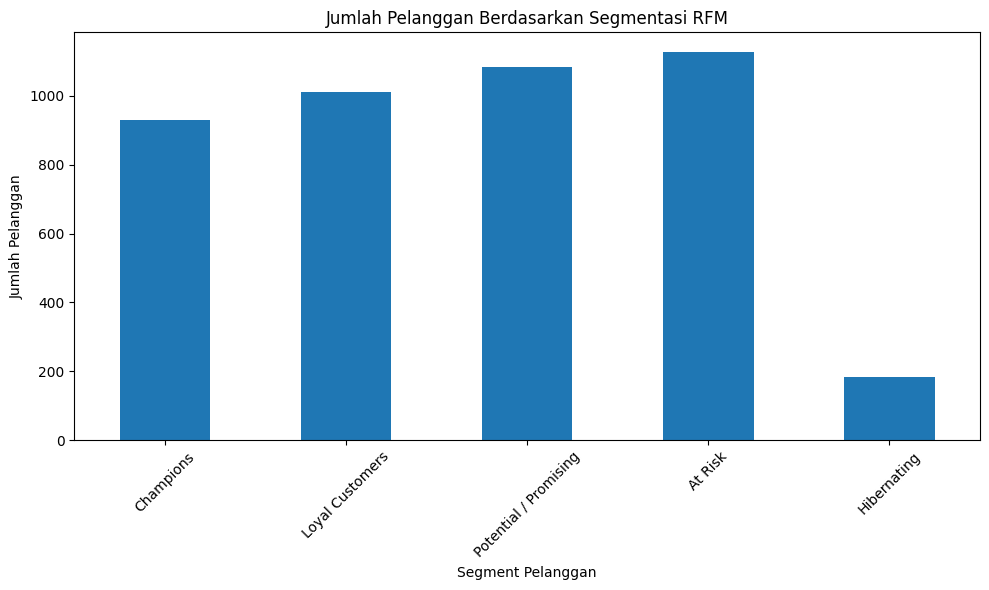

In [ ]:
# Membuat visualisasi jumlah pelanggan pada setiap segmen RFM
import matplotlib.pyplot as plt

segment_count = (
    rfm["Segment"]
    .value_counts()
    .reindex([
        "Champions",
        "Loyal Customers",
        "Potential / Promising",
        "At Risk",
        "Hibernating"
    ])
)

plt.figure(figsize=(10, 6))
segment_count.plot(kind="bar")

plt.title("Jumlah Pelanggan Berdasarkan Segmentasi RFM")
plt.xlabel("Segment Pelanggan")
plt.ylabel("Jumlah Pelanggan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretasi sementara segmentasi RFM

Berdasarkan hasil segmentasi terhadap 4.338 pelanggan, terlihat bahwa At Risk merupakan segmen dengan jumlah pelanggan paling besar, yaitu 1.128 pelanggan (26,00%). Ini menunjukkan bahwa cukup banyak pelanggan yang sebelumnya memiliki aktivitas pembelian, tetapi saat ini sudah mulai tidak aktif dan berpotensi berhenti melakukan pembelian.

Selanjutnya, terdapat 1.085 pelanggan (25,01%) dalam segmen Potential / Promising. Jumlah yang besar pada segmen ini menunjukkan adanya peluang untuk meningkatkan loyalitas pelanggan melalui strategi seperti penawaran khusus, rekomendasi produk, atau program loyalitas.

Segmen Loyal Customers terdiri dari 1.012 pelanggan (23,33%). Kelompok ini memiliki hubungan yang relatif baik dengan perusahaan karena memiliki frekuensi dan nilai pembelian yang cukup tinggi. Pelanggan dalam segmen ini perlu dipertahankan agar dapat berkembang menjadi pelanggan bernilai lebih tinggi.

Sementara itu, Champions berjumlah 929 pelanggan (21,42%). Walaupun jumlahnya bukan yang terbesar, segmen ini merupakan kelompok yang sangat penting karena pelanggan Champions memiliki nilai pembelian dan aktivitas yang sangat tinggi. Berdasarkan analisis sebelumnya, segmen ini hanya sekitar 21% pelanggan tetapi menyumbang sekitar £6,23 juta dari total monetary pelanggan yang dianalisis.

Terakhir, Hibernating merupakan segmen terkecil dengan 184 pelanggan (4,24%). Kelompok ini memiliki aktivitas pembelian yang rendah dan sudah cukup lama tidak melakukan transaksi, sehingga kemungkinan untuk kembali aktif lebih rendah dibandingkan segmen lainnya.

In [ ]:
# Menghitung rata-rata Recency, Frequency, dan Monetary untuk setiap segmen pelanggan untuk mengetahui kenapa pelanggan masuk ke segmen tertentu
segment_rfm = (
    rfm.groupby("Segment")
    .agg(
        average_recency=("Recency", "mean"),
        average_frequency=("Frequency", "mean"),
        average_monetary=("Monetary", "mean")
    )
    .reset_index()
)

segment_rfm = segment_rfm.reindex(
    segment_rfm["Segment"].map({
        "Champions": 1,
        "Loyal Customers": 2,
        "Potential / Promising": 3,
        "At Risk": 4,
        "Hibernating": 5
    }).sort_values().index
)

print(segment_rfm)

                 Segment  average_recency  average_frequency  average_monetary
1              Champions        13.518837          11.779333       6705.386911
3        Loyal Customers        42.347826           3.866601       1395.829388
4  Potential / Promising        84.541935           2.013825        809.758269
0                At Risk       175.110816           1.158688        301.541650
2            Hibernating       284.875000           1.000000        144.556576


**Interpretasi berdasarkan rata-rata RFM**

| Segment | Recency | Frequency | Monetary | Interpretasi |
| ------------------------- | ----------: | --------------: | --------: | ------------------------------------- |
| **Champions** | 13,52 hari | 11,78 transaksi | £6.705,39 | Sangat aktif dan bernilai tinggi |
| **Loyal Customers** | 42,35 hari | 3,87 transaksi | £1.395,83 | Cukup aktif dan loyal |
| **Potential / Promising** | 84,54 hari | 2,01 transaksi | £809,76 | Masih berpotensi berkembang |
| **At Risk** | 175,11 hari | 1,16 transaksi | £301,54 | Mulai tidak aktif dan berisiko hilang |
| **Hibernating** | 284,88 hari | 1,00 transaksi | £144,56 | Sangat lama tidak bertransaksi |

## Interpretasi Rata-rata RFM Berdasarkan Segmentasi

Berdasarkan nilai rata-rata Recency, Frequency, dan Monetary pada setiap segmen, terdapat beberapa karakteristik utama:

### 1. Champions merupakan pelanggan dengan nilai tertinggi

Champions memiliki rata-rata Recency sebesar 13,52 hari, yang menunjukkan bahwa mereka relatif baru melakukan pembelian. Mereka juga rata-rata melakukan 11,78 transaksi dengan nilai Monetary sekitar £6.705 per pelanggan.

Hasil ini menunjukkan bahwa segmentasi Champions sesuai dengan karakteristik pelanggan bernilai tinggi, yaitu pelanggan yang aktif melakukan pembelian dan memberikan kontribusi Monetary yang besar.

### 2. Loyal Customers menunjukkan pola pembelian yang relatif stabil

Loyal Customers memiliki rata-rata Recency sekitar 42 hari, dengan rata-rata Frequency hampir 4 transaksi dan Monetary sekitar £1.396 per pelanggan.

Kelompok ini menunjukkan pola pembelian yang cukup stabil dan memiliki potensi untuk dikembangkan menjadi Champions melalui strategi peningkatan engagement dan frekuensi pembelian.

### 3. Potential / Promising memiliki peluang untuk dikembangkan

Potential / Promising memiliki rata-rata Recency sekitar 84,5 hari, dengan rata-rata 2 transaksi dan Monetary sebesar £809,76 per pelanggan.

Meskipun tingkat aktivitasnya belum setinggi Champions atau Loyal Customers, kelompok ini telah menunjukkan nilai pembelian yang cukup besar. Oleh karena itu, kelompok ini memiliki peluang untuk dikembangkan melalui promosi yang lebih personal, rekomendasi produk, cross-selling, upselling, atau program loyalitas.

### 4. At Risk merupakan kelompok yang perlu mendapatkan perhatian

At Risk memiliki rata-rata Recency sekitar 175 hari, dengan rata-rata Frequency hanya 1,16 transaksi dan Monetary sekitar £301,54 per pelanggan.

Selain memiliki jumlah pelanggan yang cukup besar, yaitu 1.128 pelanggan, karakteristik tersebut menunjukkan adanya risiko pelanggan menjadi tidak aktif. Kelompok ini dapat menjadi target utama untuk strategi retensi dan reaktivasi pelanggan.

### 5. Hibernating memiliki tingkat aktivitas paling rendah

Hibernating memiliki rata-rata Recency sekitar 285 hari, dengan rata-rata Frequency hanya 1 transaksi dan Monetary sekitar £144,56 per pelanggan.

Karakteristik tersebut menunjukkan bahwa kelompok Hibernating merupakan pelanggan dengan tingkat aktivitas paling rendah dan telah cukup lama tidak melakukan transaksi. Strategi reaktivasi dapat diterapkan untuk mengidentifikasi pelanggan yang masih memiliki kemungkinan untuk kembali melakukan pembelian.

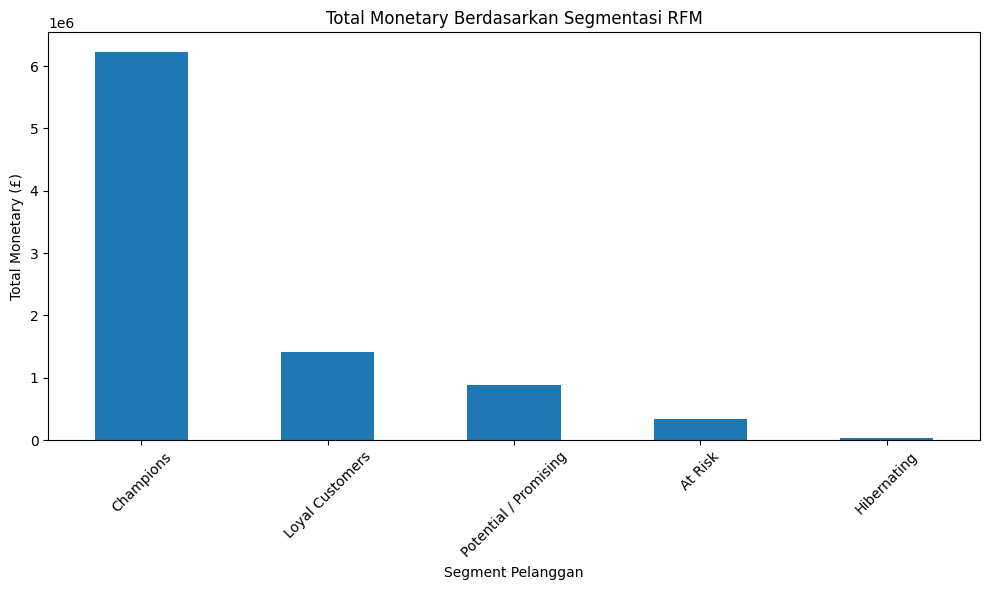

In [ ]:
# Membuat visualisasi total nilai pembelian (Monetary) berdasarkan segmen RFM
segment_monetary = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .reindex([
        "Champions",
        "Loyal Customers",
        "Potential / Promising",
        "At Risk",
        "Hibernating"
    ])
)

plt.figure(figsize=(10, 6))
segment_monetary.plot(kind="bar")

plt.title("Total Monetary Berdasarkan Segmentasi RFM")
plt.xlabel("Segment Pelanggan")
plt.ylabel("Total Monetary (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretasi Total Monetary per Segmen**

Dari grafik terlihat adanya perbedaan yang sangat besar antara Champions dan segmen lainnya.

| Segment | Jumlah Pelanggan | Total Monetary | Kontribusi |
| ------------------------- | ---------------: | -------------: | ----------: |
| **Champions** | 929 | £6.229.304,44 | **≈ 70,1%** |
| **Loyal Customers** | 1.012 | £1.412.579,34 | ≈ 15,9% |
| **Potential / Promising** | 1.085 | £878.587,72 | ≈ 9,9% |
| **At Risk** | 1.128 | £340.138,98 | ≈ 3,8% |
| **Hibernating** | 184 | £26.598,41 | ≈ 0,3% |

Persentase dihitung terhadap total Monetary pelanggan yang memiliki CustomerID.

 Insight paling penting

Champions hanya sekitar 21,4% dari jumlah pelanggan, tetapi menghasilkan sekitar 70,1% dari total Monetary RFM.

Ini merupakan insight bisnis yang sangat kuat.

Artinya, perusahaan memiliki kelompok pelanggan yang relatif kecil tetapi memberikan kontribusi nilai yang sangat besar. Karena itu, pelanggan Champions harus menjadi prioritas utama dalam strategi customer retention.

Sebaliknya, At Risk memiliki jumlah pelanggan terbesar, yaitu 1.128 pelanggan atau sekitar 26%, tetapi kontribusinya hanya sekitar 3,8%.

Jadi kita mendapatkan kondisi yang menarik:

Jumlah pelanggan terbesar bukan berarti memberikan revenue terbesar.

Hal ini menunjukkan pentingnya melakukan segmentasi pelanggan menggunakan RFM, karena kalau perusahaan hanya melihat jumlah pelanggan, perusahaan bisa salah menentukan prioritas.

 Dari sisi strategi bisnis

Hasil ini mulai bisa kita terjemahkan menjadi strategi:

 Champions → pertahankan dengan program loyalitas, exclusive offer, early access, dan apresiasi pelanggan.
 Loyal Customers → dorong agar menjadi Champions melalui peningkatan frekuensi dan nilai pembelian.
 Potential / Promising → berikan rekomendasi dan promo yang mendorong pembelian berikutnya.
️ At Risk → lakukan win-back campaign untuk mengaktifkan kembali pelanggan.
 Hibernating → lakukan reactivation campaign dengan biaya yang terukur karena nilai ekonominya relatif rendah.
Untuk laporan kita

Insight ini bisa ditulis lebih profesional seperti:

Analisis Monetary menunjukkan bahwa segmen Champions memiliki kontribusi nilai pelanggan yang sangat dominan. Meskipun hanya mencakup 21,42% dari total pelanggan, segmen ini menghasilkan sekitar 70,1% dari total Monetary pelanggan yang dianalisis. Sebaliknya, segmen At Risk merupakan segmen dengan jumlah pelanggan terbesar, yaitu 26,00%, tetapi hanya memberikan kontribusi sekitar 3,8% terhadap total Monetary. Temuan ini menunjukkan bahwa jumlah pelanggan tidak secara langsung mencerminkan nilai ekonomi pelanggan, sehingga segmentasi RFM dapat membantu perusahaan menentukan prioritas strategi retensi dan pengembangan pelanggan secara lebih tepat.

In [ ]:
# Mengidentifikasi 10 pelanggan Champions dengan nilai pembelian (Monetary) tertinggi
top_champions = (
    rfm[rfm["Segment"] == "Champions"]
    .sort_values("Monetary", ascending=False)
    [["CustomerID", "Recency", "Frequency", "Monetary", "RFM_Score"]]
    .head(10)
)

print(top_champions.to_string(index=False))

 CustomerID  Recency  Frequency  Monetary RFM_Score
    14646.0        1         73 280206.02       555
    18102.0        0         60 259657.30       555
    17450.0        7         46 194390.79       555
    16446.0        0          2 168472.50       535
    14911.0        0        201 143711.17       555
    12415.0       23         21 124914.53       455
    14156.0        9         55 117210.08       555
    17511.0        2         31  91062.38       555
    16029.0       38         63  80850.84       355
    16684.0        3         28  66653.56       555


## Interpretasi Top 10 Champions

Beberapa pola utama dapat dilihat dari hasil analisis Top 10 Champions:

### 1. Customer 14646 memiliki nilai Monetary tertinggi

Customer 14646 menghasilkan Monetary sebesar £280.206,02 dengan:

- Recency = 1 hari
- Frequency = 73 transaksi
- RFM Score = 555

Customer ini merupakan contoh Champions yang sangat kuat karena memiliki transaksi yang relatif baru, frekuensi pembelian yang tinggi, serta nilai pembelian yang besar.

### 2. Customer 18102 menunjukkan pola pembelian yang sangat kuat

Customer 18102 menghasilkan Monetary sebesar £259.657,30 dengan Frequency sebanyak 60 transaksi dan Recency 0 hari. Kombinasi tersebut menunjukkan tingkat aktivitas dan nilai pelanggan yang sangat tinggi.

### 3. Tidak semua Champions memiliki Frequency yang tinggi

Salah satu temuan yang menarik adalah Customer 16446. Customer ini menghasilkan Monetary sebesar £168.472,50, tetapi hanya memiliki 2 transaksi.

Customer tersebut tetap masuk dalam segmen Champions karena memiliki nilai Monetary yang sangat tinggi dan transaksi terakhir yang relatif baru. Hal ini menunjukkan bahwa pelanggan dengan nilai tinggi tidak selalu merupakan pelanggan dengan frekuensi transaksi yang tinggi.

Temuan ini menunjukkan bahwa segmentasi RFM mempertimbangkan kombinasi Recency, Frequency, dan Monetary, bukan hanya frekuensi pembelian.

### 4. Customer 14911 memiliki Frequency yang sangat tinggi

Customer 14911 memiliki 201 transaksi, yang merupakan Frequency tertinggi di antara Top 10 Champions. Customer ini juga memiliki Monetary sebesar £143.711,17 dan Recency 0 hari.

Kombinasi tersebut menunjukkan bahwa Customer 14911 merupakan pelanggan yang sangat aktif dan melakukan pembelian secara berulang.

## Insight Bisnis dari Top 10 Champions

Berdasarkan Top 10 Champions, dapat disimpulkan bahwa pelanggan bernilai tinggi memiliki karakteristik yang beragam. Sebagian pelanggan memiliki frekuensi transaksi yang tinggi, sedangkan sebagian lainnya menghasilkan nilai pembelian yang besar meskipun frekuensi transaksinya relatif rendah.

Oleh karena itu, strategi retensi pelanggan sebaiknya mempertimbangkan kombinasi Recency, Frequency, dan Monetary, bukan hanya frekuensi pembelian.

Customer 16446 juga menjadi contoh yang relevan dalam memahami hasil RFM. Meskipun hanya melakukan 2 transaksi, nilai Monetary yang sangat tinggi dan transaksi yang relatif baru membuatnya masuk ke dalam segmen Champions. Temuan ini dapat menjadi contoh ketika menjelaskan bahwa segmentasi RFM tidak hanya ditentukan oleh jumlah transaksi.

## Kesimpulan Analisis RFM

Berdasarkan hasil analisis RFM, terdapat tiga temuan utama:

- **Champions** mencakup 21,42% pelanggan dan menyumbang sekitar 70,1% dari total Monetary pelanggan yang dianalisis.
- **At Risk** merupakan segmen terbesar dengan 26,00% pelanggan, sehingga menjadi kelompok penting untuk strategi retensi dan reaktivasi.
- **Potential / Promising** mencakup 25,01% pelanggan dan menjadi kelompok yang memiliki peluang untuk dikembangkan menjadi pelanggan Loyal Customers atau Champions.

Dengan demikian, analisis RFM telah memberikan gambaran mengenai karakteristik dan nilai masing-masing kelompok pelanggan. Hasil ini selanjutnya dapat digunakan sebagai dasar untuk menyusun Business Insights dan Recommendations.

In [ ]:
# Membuat ringkasan KPI utama sebagai dasar penyusunan business insights
total_revenue = sales_df["Revenue"].sum()
total_transactions = sales_df["InvoiceNo"].nunique()
total_customers = sales_df["CustomerID"].nunique()
average_order_value = total_revenue / total_transactions

champions_customers = (rfm["Segment"] == "Champions").sum()
champions_revenue = rfm.loc[
    rfm["Segment"] == "Champions", "Monetary"
].sum()

at_risk_customers = (rfm["Segment"] == "At Risk").sum()
hibernating_customers = (rfm["Segment"] == "Hibernating").sum()

potential_customers = (rfm["Segment"] == "Potential / Promising").sum()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Transactions",
        "Total Customers",
        "Average Order Value",
        "Champions Customers",
        "Champions Monetary",
        "At Risk Customers",
        "Hibernating Customers",
        "Potential / Promising Customers"
    ],
    "Value": [
        total_revenue,
        total_transactions,
        total_customers,
        average_order_value,
        champions_customers,
        champions_revenue,
        at_risk_customers,
        hibernating_customers,
        potential_customers
    ]
})

print(kpi_summary.to_string(index=False))

                            KPI        Value
                  Total Revenue 1.064211e+07
             Total Transactions 1.996000e+04
                Total Customers 4.338000e+03
            Average Order Value 5.331719e+02
            Champions Customers 9.290000e+02
             Champions Monetary 6.229304e+06
              At Risk Customers 1.128000e+03
          Hibernating Customers 1.840000e+02
Potential / Promising Customers 1.085000e+03


**Tabel Business Insight**

| Temuan | Bukti dari Data | Dampak Bisnis | Rekomendasi |
| ---------------------------------------------------- | ----------------------------------------------- | --------------------------------------------------- | --------------------------------------------- |
| Revenue meningkat menjelang akhir tahun | November = ±£1,50 juta, tertinggi | Demand tinggi pada periode tertentu | Persiapkan stok & promosi sebelum peak season |
| Beberapa produk menjadi kontributor revenue terbesar | Top products memiliki revenue jauh lebih tinggi | Produk utama berpengaruh besar terhadap penjualan | Prioritaskan stok dan promosi produk unggulan |
| Champions sangat bernilai | 21,42% pelanggan → ±70,1% Monetary | Kehilangan pelanggan ini berpotensi berdampak besar | Loyalty program & exclusive offers |
| At Risk merupakan segmen terbesar | 1.128 pelanggan / 26% | Risiko customer churn cukup besar | Win-back & personalized promotion |
| Potential / Promising cukup besar | 1.085 pelanggan / 25,01% | Ada basis pelanggan yang bisa dikembangkan | Cross-selling, upselling, dan loyalty program |

In [ ]:
# Membuat file SQL dari query analisis agar proses SQL dapat ditampilkan dalam portofolio GitHub

sql_content = """
-- 1. Total Revenue
SELECT
    SUM(Revenue) AS total_revenue
FROM sales;

-- 2. Total Transactions
SELECT
    COUNT(DISTINCT InvoiceNo) AS total_transactions
FROM sales;

-- 3. Total Customers
SELECT
    COUNT(DISTINCT CustomerID) AS total_customers
FROM sales
WHERE CustomerID IS NOT NULL;

-- 4. Average Order Value (AOV)
SELECT
    SUM(Revenue) / COUNT(DISTINCT InvoiceNo) AS AOV
FROM sales;

-- 5. Monthly Revenue
SELECT
    strftime('%Y-%m', InvoiceDate) AS year_month,
    SUM(Revenue) AS monthly_revenue
FROM sales
GROUP BY year_month
ORDER BY year_month;

-- 6. Top 10 Products by Revenue
SELECT
    StockCode,
    Description,
    SUM(Quantity) AS total_quantity,
    SUM(Revenue) AS total_revenue
FROM sales
WHERE StockCode NOT IN (
    'POST', 'DOT', 'M', 'D',
    'AMAZONFEE', 'CRUK', 'B'
)
GROUP BY StockCode, Description
ORDER BY total_revenue DESC
LIMIT 10;

-- 7. Top 10 Customers by Revenue
SELECT
    CustomerID,
    COUNT(DISTINCT InvoiceNo) AS total_transactions,
    SUM(Revenue) AS total_revenue
FROM sales
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY total_revenue DESC
LIMIT 10;

-- 8. Top 10 Countries by Revenue
SELECT
    Country,
    SUM(Revenue) AS total_revenue
FROM sales
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10;

-- 9. Top 10 Products by Quantity
SELECT
    StockCode,
    Description,
    SUM(Quantity) AS total_quantity
FROM sales
WHERE StockCode NOT IN (
    'POST', 'DOT', 'M', 'D',
    'AMAZONFEE', 'CRUK', 'B'
)
GROUP BY StockCode, Description
ORDER BY total_quantity DESC
LIMIT 10;
"""

# Menentukan lokasi file SQL di folder SQL pada Google Drive
sql_path = "/content/drive/MyDrive/Sales-Customer-Analytics/SQL/sales_analysis.sql"

with open(sql_path, "w", encoding="utf-8") as file:
    file.write(sql_content)

print("File SQL berhasil dibuat:")
print(sql_path)

File SQL berhasil dibuat:
/content/drive/MyDrive/Sales-Customer-Analytics/SQL/sales_analysis.sql


In [ ]:
# Mengecek folder proyek dan melihat isi folder Sales-Customer-Analytics di Google Drive

import os

project_path = "/content/drive/MyDrive/Sales-Customer-Analytics"

print("Folder proyek ada:", os.path.exists(project_path))

if os.path.exists(project_path):
    print("\nIsi folder:")
    print(os.listdir(project_path))

Folder proyek ada: True

Isi folder:
['SQL', 'data', 'notebook']


In [ ]:
# Mengecek ukuran file project sebelum menentukan file mana yang aman di-upload ke GitHub

import os

files = [
    "/content/drive/MyDrive/Sales-Customer-Analytics/data/cleaned_data.csv",
    "/content/drive/MyDrive/Sales-Customer-Analytics/data/sales_data.csv",
    "/content/drive/MyDrive/Sales-Customer-Analytics/data/rfm_customer.csv",
    "/content/drive/MyDrive/Sales-Customer-Analytics/notebook/01_data_understanding.ipynb",
    "/content/drive/MyDrive/Sales-Customer-Analytics/SQL/sales_customer.db",
    "/content/drive/MyDrive/Sales-Customer-Analytics/SQL/sales_analysis.sql"
]

for file_path in files:
    if os.path.exists(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"{os.path.basename(file_path)}: {size_mb:.2f} MB")
    else:
        print(f"{os.path.basename(file_path)}: FILE TIDAK DITEMUKAN")

cleaned_data.csv: 45.36 MB
sales_data.csv: 48.01 MB
rfm_customer.csv: 0.20 MB
01_data_understanding.ipynb: 0.42 MB
sales_customer.db: 52.79 MB
sales_analysis.sql: 0.00 MB


In [ ]:
# Mengecek ukuran file Power BI sebelum menentukan cara penyimpanannya di GitHub

import os

dashboard_path = "/content/drive/MyDrive/Sales-Customer-Analytics/Sales_Customer_Analytics.pbix"

if os.path.exists(dashboard_path):
    size_mb = os.path.getsize(dashboard_path) / (1024 * 1024)
    print(f"Ukuran file Power BI: {size_mb:.2f} MB")
else:
    print("File Power BI tidak ditemukan di lokasi tersebut.")

Ukuran file Power BI: 3.64 MB
